# Vigor Dimensions — NB4: Clinical Prediction

Tests whether choice model parameters and vigor dimensions predict psychiatric symptom
factors, and whether different behavioral domains carry different clinical information.

**Inputs:**
- `subject_vigor_table.csv` — 4 vigor dimensions + choice params from NB2
- `modeling_factor_param.csv` — 3 psychiatric factors + demographics

**Psychiatric factor structure** (from factor analysis on STAI, DASS-21, PHQ-9, OASIS, AMI, MFIS):
- **F1: General Wellbeing** — STAI positive affect, DASS depression (reversed), PHQ-9 mood. Higher = better wellbeing.
- **F2: Fatigue / Anergia** — MFIS items dominate, PHQ fatigue, initiative difficulty. Higher = more fatigued.
- **F3: Somatic Anxiety** — DASS anxiety (trembling, panic, breathing), STAI fear, OASIS. Higher = more anxious.

**Key hypothesis:** Energetic features (κ, tonic vigor) predict F1/F2 (depression/fatigue),
while threat-reactive features (β, z, anticipatory/reactive/terminal vigor) predict F3 (anxiety).


In [2]:
# ── SETUP ─────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr, zscore, f as f_dist
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──
DATA_PROC = Path('../../data/processed')
DATA_RAW  = Path('../../data/raw')
RESULTS   = Path('../../results')
FIG_DIR   = Path('../../figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

DPI = 150
plt.style.use('seaborn-v0_8-whitegrid')


## Section 1: Load & Merge Data

Merge vigor dimensions (from NB2) with psychiatric factor scores.
The factor CSV uses `subject` as ID; the vigor table uses `subj`.

In [3]:
# ── Load vigor dimensions + choice parameters from NB2 ──
vigor_df = pd.read_csv(DATA_PROC / 'subject_vigor_table.csv')
print(f'Vigor table: {vigor_df.shape[0]} subjects')

# ── Load psychiatric factor scores + demographics ──
# ADJUST PATH if needed
factor_df = pd.read_csv(DATA_RAW / 'modeling_factor_param.csv')
factor_df = factor_df.rename(columns={'subject': 'subj'})
print(f'Factor table: {factor_df.shape[0]} subjects')

# ── Merge on subj ──
df = vigor_df.merge(factor_df[['subj', 'F1', 'F2', 'F3', 'Age', 'Sex']],
                     on='subj', how='inner')
print(f'Merged: {len(df)} subjects')

# ── Define predictor groups ──
choice_cols = ['kappa_z', 'z_z', 'beta_z']
vigor_dims  = ['tonic_vigor', 'anticipatory_mobilization', 'reactive_spike', 'terminal_persistence']
factor_cols = ['F1', 'F2', 'F3']
factor_labels = {
    'F1': 'F1: Wellbeing',
    'F2': 'F2: Fatigue',
    'F3': 'F3: Somatic Anxiety',
}

# ── Drop incomplete cases ──
all_cols = choice_cols + vigor_dims + factor_cols
df_complete = df.dropna(subset=all_cols).copy()
print(f'Complete cases: {len(df_complete)} / {len(df)}')

# Descriptives
print('\nPsychiatric factor descriptives:')
print(df_complete[factor_cols + ['Age']].describe().round(3))
print(f'\nSex: {df_complete["Sex"].value_counts().to_dict()}')


Vigor table: 292 subjects
Factor table: 291 subjects
Merged: 290 subjects
Complete cases: 290 / 290

Psychiatric factor descriptives:
            F1       F2       F3      Age
count  290.000  290.000  290.000  290.000
mean     0.005    0.004    0.002    0.002
std      1.000    1.001    1.003    1.003
min     -1.866   -1.829   -1.949   -1.499
25%     -0.772   -0.857   -0.712   -0.784
50%     -0.120    0.062   -0.259   -0.158
75%      0.714    0.755    0.629    0.556
max      3.200    2.490    4.436    3.416

Sex: {'Male': 165, 'Female': 124, 'Prefer not to say': 1}


## Section 2: Bivariate Correlations

Full correlation matrix: 3 choice params × 4 vigor dims × 3 factors.
Identifies which behavioral features relate to which psychiatric outcomes.

In [4]:
# ── 7×3 correlation matrix: all predictors × psychiatric factors ──

pred_cols = choice_cols + vigor_dims
pred_labels = ['κ (effort disc.)', 'z (hazard sens.)', 'β (threat bias)',
               'Tonic Vigor', 'Antic. Mobil.', 'Reactive Spike', 'Terminal Persist.']
fac_labels = ['F1: Wellbeing', 'F2: Fatigue', 'F3: Somatic Anxiety']

corr_vals = np.zeros((len(pred_cols), 3))
p_vals = np.zeros((len(pred_cols), 3))

for i, pc in enumerate(pred_cols):
    for j, fc in enumerate(factor_cols):
        r, p = pearsonr(df_complete[pc], df_complete[fc])
        corr_vals[i, j] = r
        p_vals[i, j] = p

# Print table
print('Bivariate Correlations: Predictors × Psychiatric Factors')
print('=' * 80)
print(f'{"":25s}', end='')
for fl in fac_labels:
    print(f'{fl:>18s}', end='')
print()
print('-' * 80)

for i, pl in enumerate(pred_labels):
    print(f'{pl:25s}', end='')
    for j in range(3):
        r, p = corr_vals[i, j], p_vals[i, j]
        stars = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        print(f'  r={r:+.3f}{stars:4s}', end='')
    print()

print('=' * 80)
print(f'N = {len(df_complete)}')


Bivariate Correlations: Predictors × Psychiatric Factors
                              F1: Wellbeing       F2: FatigueF3: Somatic Anxiety
--------------------------------------------------------------------------------
κ (effort disc.)           r=-0.029      r=-0.083      r=+0.003    
z (hazard sens.)           r=+0.002      r=-0.160**    r=-0.152**  
β (threat bias)            r=+0.075      r=-0.020      r=-0.034    
Tonic Vigor                r=+0.133*     r=+0.084      r=-0.137*   
Antic. Mobil.              r=+0.068      r=+0.019      r=-0.059    
Reactive Spike             r=-0.027      r=-0.104      r=-0.018    
Terminal Persist.          r=-0.036      r=-0.016      r=-0.065    
N = 290


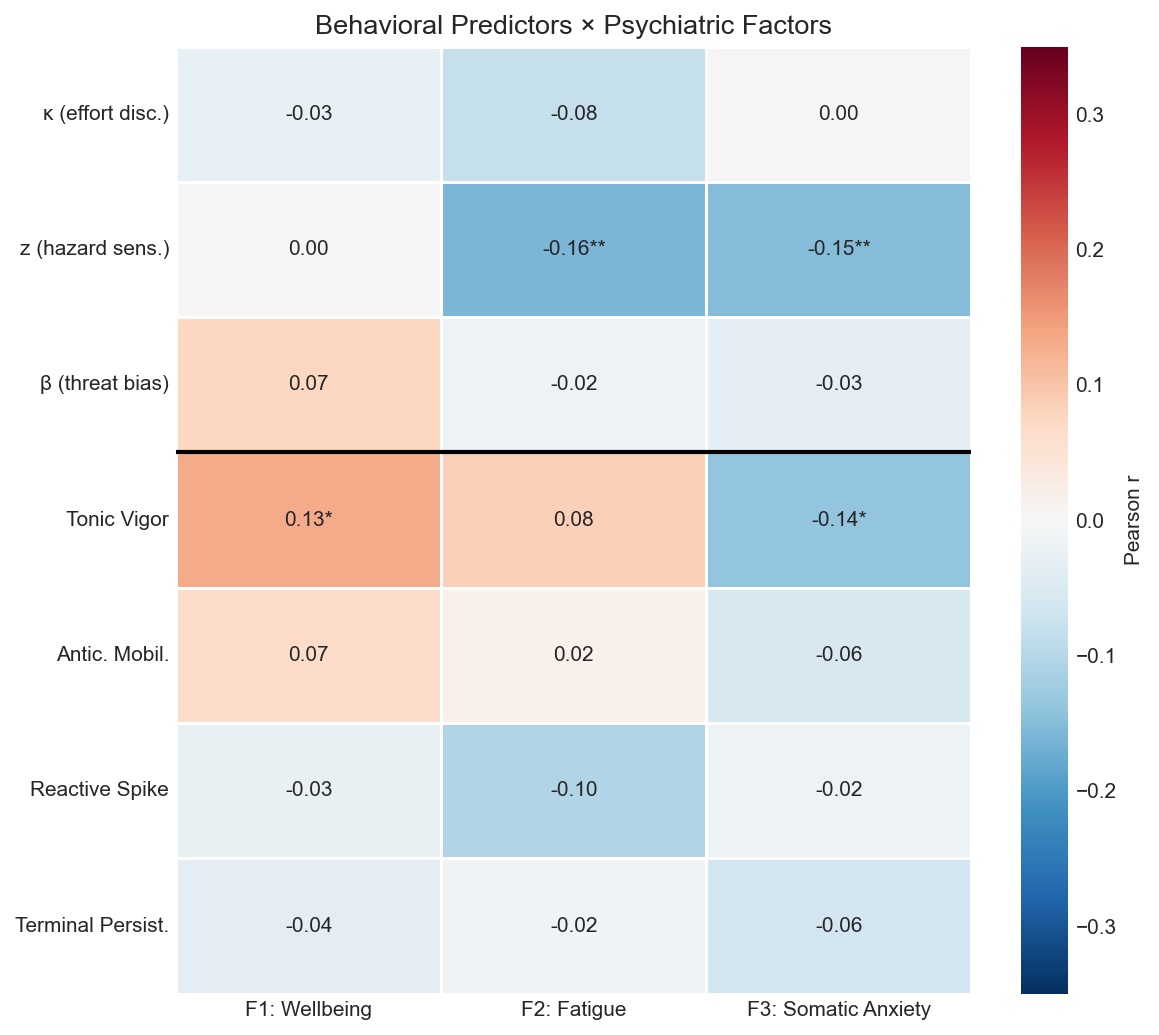

In [5]:
# ── Heatmap figure ──

annot = np.empty((len(pred_cols), 3), dtype=object)
for i in range(len(pred_cols)):
    for j in range(3):
        r, p = corr_vals[i, j], p_vals[i, j]
        stars = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        annot[i, j] = f'{r:.2f}{stars}'

corr_df = pd.DataFrame(corr_vals, index=pred_labels, columns=fac_labels)

fig, ax = plt.subplots(figsize=(8, 7), dpi=DPI)
sns.heatmap(corr_df, annot=annot, fmt='', center=0, cmap='RdBu_r',
            vmin=-0.35, vmax=0.35, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})

# Add horizontal divider between choice and vigor blocks
ax.axhline(3, color='black', linewidth=2)
ax.set_title('Behavioral Predictors × Psychiatric Factors', fontsize=13)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb4_corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## Section 3: Model Comparison — Does Vigor Add to Choice?

For each psychiatric factor, fit three models:
- **Model A**: Choice only (κ, z, β) — 3 predictors
- **Model B**: Vigor only (4 dimensions) — 4 predictors
- **Model C**: Combined (7 predictors)

Test incremental prediction: does adding vigor to choice improve fit (F-test)?

In [6]:
# ── Model comparison ──

choice_formula = ' + '.join(choice_cols)
vigor_formula  = ' + '.join(vigor_dims)
full_formula   = choice_formula + ' + ' + vigor_formula

model_results = []

for fc in factor_cols:
    fl = factor_labels[fc]

    # Model A: Choice only
    fit_a = smf.ols(f'{fc} ~ {choice_formula}', data=df_complete).fit()

    # Model B: Vigor only
    fit_b = smf.ols(f'{fc} ~ {vigor_formula}', data=df_complete).fit()

    # Model C: Combined
    fit_c = smf.ols(f'{fc} ~ {full_formula}', data=df_complete).fit()

    # Incremental F-test: vigor added to choice (A → C)
    df_num_vc = fit_c.df_model - fit_a.df_model
    df_den_vc = fit_c.df_resid
    r2_diff_vc = fit_c.rsquared - fit_a.rsquared
    f_vc = (r2_diff_vc / df_num_vc) / ((1 - fit_c.rsquared) / df_den_vc)
    p_vc = 1 - f_dist.cdf(f_vc, df_num_vc, df_den_vc)

    # Incremental F-test: choice added to vigor (B → C)
    df_num_cv = fit_c.df_model - fit_b.df_model
    df_den_cv = fit_c.df_resid
    r2_diff_cv = fit_c.rsquared - fit_b.rsquared
    f_cv = (r2_diff_cv / df_num_cv) / ((1 - fit_c.rsquared) / df_den_cv)
    p_cv = 1 - f_dist.cdf(f_cv, df_num_cv, df_den_cv)

    print(f'\n{"="*70}')
    print(f'{fl}')
    print(f'{"─"*70}')
    print(f'  Choice only:  adj.R² = {fit_a.rsquared_adj:.4f}  (AIC = {fit_a.aic:.1f})')
    print(f'  Vigor only:   adj.R² = {fit_b.rsquared_adj:.4f}  (AIC = {fit_b.aic:.1f})')
    print(f'  Combined:     adj.R² = {fit_c.rsquared_adj:.4f}  (AIC = {fit_c.aic:.1f})')
    print(f'  ΔR² (vigor|choice): {r2_diff_vc:.4f}, F({df_num_vc:.0f},{df_den_vc:.0f}) = {f_vc:.2f}, p = {p_vc:.4f}')
    print(f'  ΔR² (choice|vigor): {r2_diff_cv:.4f}, F({df_num_cv:.0f},{df_den_cv:.0f}) = {f_cv:.2f}, p = {p_cv:.4f}')

    model_results.append({
        'outcome': fc, 'label': fl,
        'r2_choice': fit_a.rsquared_adj, 'r2_vigor': fit_b.rsquared_adj,
        'r2_combined': fit_c.rsquared_adj,
        'aic_choice': fit_a.aic, 'aic_vigor': fit_b.aic, 'aic_combined': fit_c.aic,
        'delta_r2_vigor_given_choice': r2_diff_vc, 'f_vigor_given_choice': f_vc, 'p_vigor_given_choice': p_vc,
        'delta_r2_choice_given_vigor': r2_diff_cv, 'f_choice_given_vigor': f_cv, 'p_choice_given_vigor': p_cv,
    })

model_results_df = pd.DataFrame(model_results)



F1: Wellbeing
──────────────────────────────────────────────────────────────────────
  Choice only:  adj.R² = -0.0032  (AIC = 827.8)
  Vigor only:   adj.R² = 0.0086  (AIC = 825.4)
  Combined:     adj.R² = 0.0028  (AIC = 830.0)
  ΔR² (vigor|choice): 0.0198, F(4,282) = 1.43, p = 0.2235
  ΔR² (choice|vigor): 0.0047, F(3,282) = 0.45, p = 0.7178

F2: Fatigue
──────────────────────────────────────────────────────────────────────
  Choice only:  adj.R² = 0.0184  (AIC = 822.3)
  Vigor only:   adj.R² = 0.0077  (AIC = 826.5)
  Combined:     adj.R² = 0.0249  (AIC = 824.3)
  ΔR² (vigor|choice): 0.0199, F(4,282) = 1.48, p = 0.2096
  ΔR² (choice|vigor): 0.0270, F(3,282) = 2.67, p = 0.0478

F3: Somatic Anxiety
──────────────────────────────────────────────────────────────────────
  Choice only:  adj.R² = 0.0148  (AIC = 824.2)
  Vigor only:   adj.R² = 0.0070  (AIC = 827.5)
  Combined:     adj.R² = 0.0189  (AIC = 826.9)
  ΔR² (vigor|choice): 0.0176, F(4,282) = 1.30, p = 0.2714
  ΔR² (choice|vigor): 0.

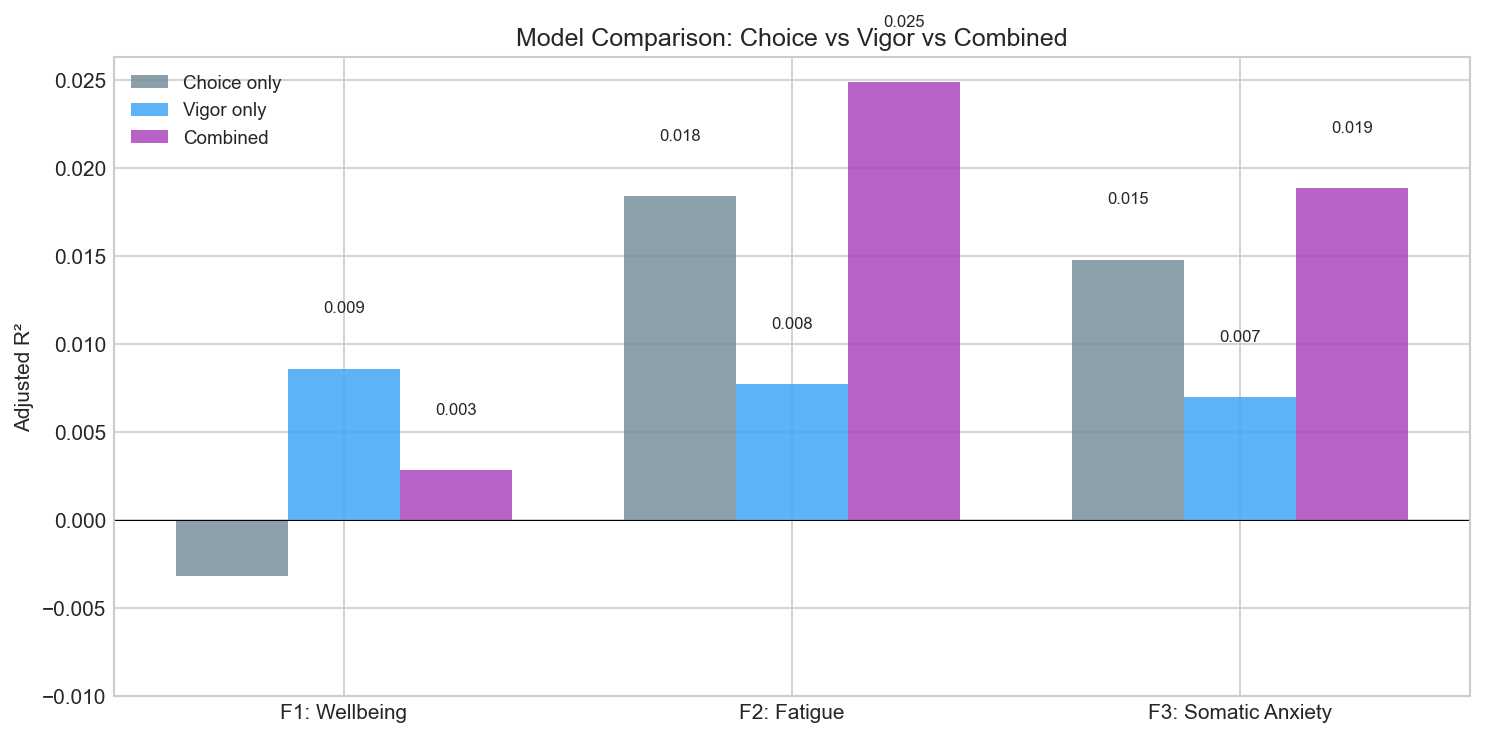

In [7]:
# ── Model comparison bar chart ──

fig, ax = plt.subplots(figsize=(10, 5), dpi=DPI)

x = np.arange(3)
width = 0.25

bars_choice = ax.bar(x - width, model_results_df['r2_choice'], width,
                      label='Choice only', color='#78909C', alpha=0.85)
bars_vigor = ax.bar(x, model_results_df['r2_vigor'], width,
                     label='Vigor only', color='#42A5F5', alpha=0.85)
bars_combined = ax.bar(x + width, model_results_df['r2_combined'], width,
                        label='Combined', color='#AB47BC', alpha=0.85)

# Add value labels
for bars in [bars_choice, bars_vigor, bars_combined]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=8)

# Add significance annotations for incremental tests
for i, row in model_results_df.iterrows():
    p = row['p_vigor_given_choice']
    if p < .05:
        stars = '***' if p < .001 else '**' if p < .01 else '*'
        ax.text(i + width, row['r2_combined'] + 0.012,
                f'Δ{stars}', ha='center', fontsize=9, color='#7B1FA2')

ax.set_xticks(x)
ax.set_xticklabels([factor_labels[f] for f in factor_cols], fontsize=10)
ax.set_ylabel('Adjusted R²')
ax.set_title('Model Comparison: Choice vs Vigor vs Combined')
ax.legend(fontsize=9)
ax.axhline(0, color='k', linewidth=0.5)
ax.set_ylim(bottom=-0.01)

plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb4_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## Section 4: Full Model Coefficients

For each factor, report all 7 predictor coefficients from the combined model.
Identifies which specific behavioral features drive prediction.

In [8]:
# ── Full model coefficients for each factor ──

coef_results = []

for fc in factor_cols:
    fl = factor_labels[fc]
    fit = smf.ols(f'{fc} ~ {full_formula}', data=df_complete).fit()

    print(f'\n{"="*70}')
    print(f'{fl}  (adj. R² = {fit.rsquared_adj:.4f}, F = {fit.fvalue:.2f}, p = {fit.f_pvalue:.4f})')
    print(f'{"─"*70}')

    for pred in choice_cols + vigor_dims:
        b = fit.params[pred]
        se = fit.bse[pred]
        p = fit.pvalues[pred]
        ci = fit.conf_int().loc[pred]
        stars = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        print(f'  {pred:30s}: β={b:+.3f}, SE={se:.3f}, p={p:.4f}{stars:4s}  '
              f'[{ci[0]:+.3f}, {ci[1]:+.3f}]')

        coef_results.append({
            'outcome': fc, 'label': fl,
            'predictor': pred,
            'beta': b, 'se': se, 'pvalue': p,
            'ci_lower': ci[0], 'ci_upper': ci[1],
            'adj_r2': fit.rsquared_adj,
        })

coef_df = pd.DataFrame(coef_results)



F1: Wellbeing  (adj. R² = 0.0028, F = 1.12, p = 0.3526)
──────────────────────────────────────────────────────────────────────
  kappa_z                       : β=-0.006, SE=0.062, p=0.9253      [-0.128, +0.117]
  z_z                           : β=-0.004, SE=0.060, p=0.9499      [-0.122, +0.114]
  beta_z                        : β=+0.070, SE=0.060, p=0.2478      [-0.049, +0.188]
  tonic_vigor                   : β=+0.235, SE=0.117, p=0.0459*     [+0.004, +0.465]
  anticipatory_mobilization     : β=+0.011, SE=0.092, p=0.9080      [-0.171, +0.193]
  reactive_spike                : β=-0.027, SE=0.062, p=0.6663      [-0.148, +0.095]
  terminal_persistence          : β=-0.090, SE=0.085, p=0.2881      [-0.257, +0.077]

F2: Fatigue  (adj. R² = 0.0249, F = 2.05, p = 0.0487)
──────────────────────────────────────────────────────────────────────
  kappa_z                       : β=-0.025, SE=0.062, p=0.6809      [-0.147, +0.096]
  z_z                           : β=-0.157, SE=0.059, p=0.0085**  

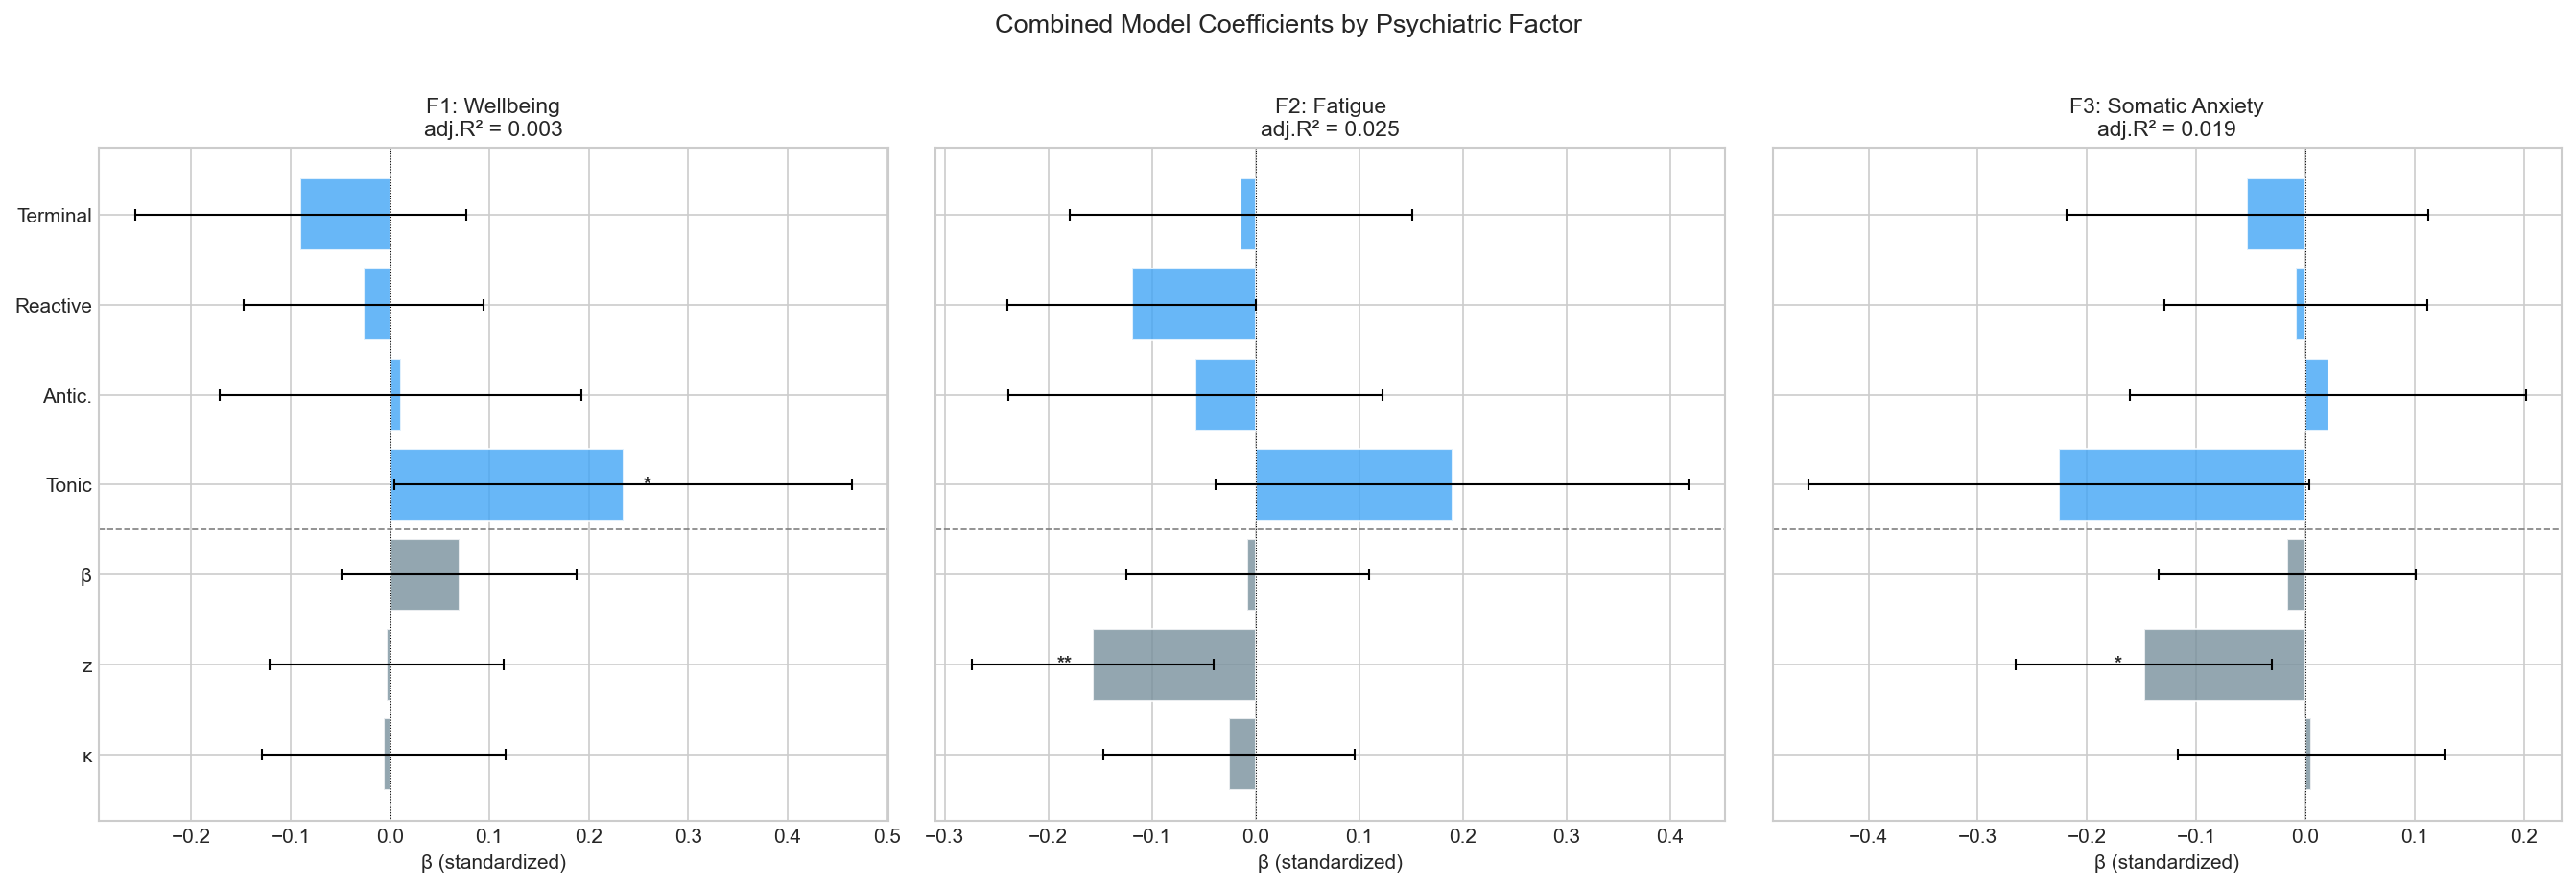

In [9]:
# ── Coefficient plot: grouped by factor ──

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=DPI, sharey=True)

pred_order = choice_cols + vigor_dims
pred_short = ['κ', 'z', 'β', 'Tonic', 'Antic.', 'Reactive', 'Terminal']
# Color by block: choice = gray, vigor = blue
bar_colors = ['#78909C']*3 + ['#42A5F5']*4

for ax, fc in zip(axes, factor_cols):
    fl = factor_labels[fc]
    subset = coef_df[coef_df['outcome'] == fc].set_index('predictor').loc[pred_order]

    y_pos = np.arange(len(pred_order))
    betas = subset['beta'].values
    ci_lo = subset['ci_lower'].values
    ci_hi = subset['ci_upper'].values
    pvals = subset['pvalue'].values

    bars = ax.barh(y_pos, betas, color=bar_colors, alpha=0.8, edgecolor='white')
    ax.errorbar(betas, y_pos, xerr=[betas - ci_lo, ci_hi - betas],
                fmt='none', color='black', linewidth=1, capsize=3)

    # Stars for significant predictors
    for i, p in enumerate(pvals):
        if p < .05:
            stars = '***' if p < .001 else '**' if p < .01 else '*'
            offset = 0.02 if betas[i] >= 0 else -0.02
            ha = 'left' if betas[i] >= 0 else 'right'
            ax.text(betas[i] + offset, i, stars, va='center', ha=ha, fontsize=10, fontweight='bold')

    ax.set_yticks(y_pos)
    if ax == axes[0]:
        ax.set_yticklabels(pred_short)
    ax.axvline(0, color='k', linewidth=0.5, linestyle=':')
    ax.set_xlabel('β (standardized)')
    r2 = subset['adj_r2'].iloc[0]
    ax.set_title(f'{fl}\nadj.R² = {r2:.3f}', fontsize=11)

    # Add horizontal divider between choice and vigor
    ax.axhline(2.5, color='gray', linewidth=0.8, linestyle='--')

plt.suptitle('Combined Model Coefficients by Psychiatric Factor', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb4_coef_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## Section 5: Energetic vs Threat-Reactive Block Dissociation

Test whether different behavioral domains carry different clinical information.

**Energetic block**: κ + tonic_vigor (2 predictors)
**Threat-reactive block**: z + β + anticipatory_mobilization + reactive_spike + terminal_persistence (5 predictors)

**Predictions:**
- F1 (wellbeing) / F2 (fatigue): energetic block significant, threat block adds little
- F3 (somatic anxiety): threat block significant, energetic block adds little

In [10]:
# ── Block-structured regression ──

energetic_preds = 'kappa_z + tonic_vigor'
threat_preds    = 'z_z + beta_z + anticipatory_mobilization + reactive_spike + terminal_persistence'
full_preds      = energetic_preds + ' + ' + threat_preds

block_results = []

for fc in factor_cols:
    fl = factor_labels[fc]

    fit_full = smf.ols(f'{fc} ~ {full_preds}', data=df_complete).fit()
    fit_ener = smf.ols(f'{fc} ~ {energetic_preds}', data=df_complete).fit()
    fit_thr  = smf.ols(f'{fc} ~ {threat_preds}', data=df_complete).fit()

    # F-test: does threat block add to energetic? (ener → full)
    df_num_t = fit_full.df_model - fit_ener.df_model
    df_den_t = fit_full.df_resid
    r2_diff_t = fit_full.rsquared - fit_ener.rsquared
    f_t = (r2_diff_t / df_num_t) / ((1 - fit_full.rsquared) / df_den_t)
    p_t = 1 - f_dist.cdf(f_t, df_num_t, df_den_t)

    # F-test: does energetic block add to threat? (thr → full)
    df_num_e = fit_full.df_model - fit_thr.df_model
    df_den_e = fit_full.df_resid
    r2_diff_e = fit_full.rsquared - fit_thr.rsquared
    f_e = (r2_diff_e / df_num_e) / ((1 - fit_full.rsquared) / df_den_e)
    p_e = 1 - f_dist.cdf(f_e, df_num_e, df_den_e)

    print(f'\n{"="*70}')
    print(f'{fl}')
    print(f'{"─"*70}')
    print(f'  Energetic only: adj.R² = {fit_ener.rsquared_adj:.4f}')
    print(f'  Threat only:    adj.R² = {fit_thr.rsquared_adj:.4f}')
    print(f'  Full model:     adj.R² = {fit_full.rsquared_adj:.4f}')
    print(f'  Threat block | energetic:  ΔR² = {r2_diff_t:.4f}, F({df_num_t:.0f},{df_den_t:.0f}) = {f_t:.2f}, p = {p_t:.4f}')
    print(f'  Energetic block | threat:  ΔR² = {r2_diff_e:.4f}, F({df_num_e:.0f},{df_den_e:.0f}) = {f_e:.2f}, p = {p_e:.4f}')

    block_results.append({
        'outcome': fc, 'label': fl,
        'r2_energetic': fit_ener.rsquared_adj, 'r2_threat': fit_thr.rsquared_adj,
        'r2_full': fit_full.rsquared_adj,
        'delta_r2_threat_block': r2_diff_t, 'f_threat_block': f_t, 'p_threat_block': p_t,
        'delta_r2_energetic_block': r2_diff_e, 'f_energetic_block': f_e, 'p_energetic_block': p_e,
    })

block_df = pd.DataFrame(block_results)



F1: Wellbeing
──────────────────────────────────────────────────────────────────────
  Energetic only: adj.R² = 0.0108
  Threat only:    adj.R² = -0.0053
  Full model:     adj.R² = 0.0028
  Threat block | energetic:  ΔR² = 0.0094, F(5,282) = 0.54, p = 0.7434
  Energetic block | threat:  ΔR² = 0.0149, F(2,282) = 2.16, p = 0.1171

F2: Fatigue
──────────────────────────────────────────────────────────────────────
  Energetic only: adj.R² = 0.0045
  Threat only:    adj.R² = 0.0203
  Full model:     adj.R² = 0.0249
  Threat block | energetic:  ΔR² = 0.0371, F(5,282) = 2.20, p = 0.0544
  Energetic block | threat:  ΔR² = 0.0112, F(2,282) = 1.66, p = 0.1920

F3: Somatic Anxiety
──────────────────────────────────────────────────────────────────────
  Energetic only: adj.R² = 0.0129
  Threat only:    adj.R² = 0.0118
  Full model:     adj.R² = 0.0189
  Threat block | energetic:  ΔR² = 0.0229, F(5,282) = 1.35, p = 0.2428
  Energetic block | threat:  ΔR² = 0.0137, F(2,282) = 2.02, p = 0.1346


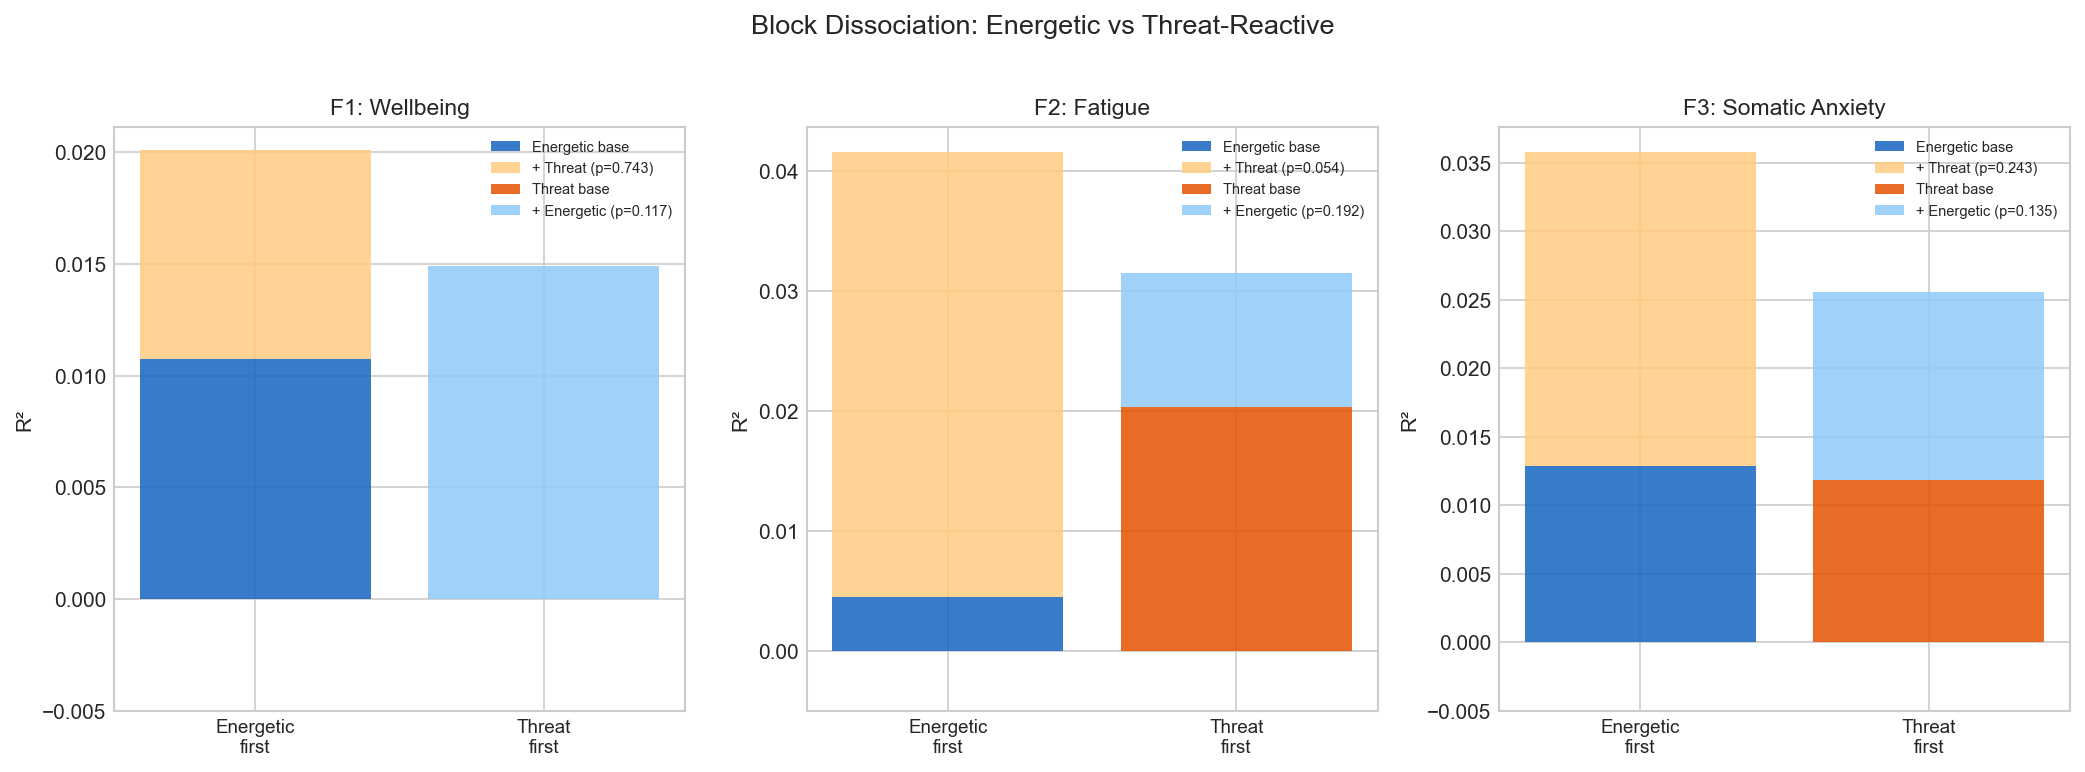

In [11]:
# ── Dissociation figure ──
# For each factor, show energetic block R² and incremental threat R²

fig, axes = plt.subplots(1, 3, figsize=(14, 5), dpi=DPI)

for ax, (_, row) in zip(axes, block_df.iterrows()):
    fl = row['label']

    # Stacked bar: energetic base + threat increment
    ener_r2 = max(0, row['r2_energetic'])
    threat_incr = max(0, row['delta_r2_threat_block'])
    # And reverse: threat base + energetic increment
    threat_r2 = max(0, row['r2_threat'])
    ener_incr = max(0, row['delta_r2_energetic_block'])

    x = [0, 1]
    # Bar 1: energetic (base) + threat (increment)
    ax.bar(0, ener_r2, color='#1565C0', alpha=0.85, label='Energetic base')
    p_t = row['p_threat_block']
    t_color = '#E65100' if p_t < .05 else '#FFCC80'
    ax.bar(0, threat_incr, bottom=ener_r2, color=t_color, alpha=0.85,
           label=f'+ Threat (p={p_t:.3f})')

    # Bar 2: threat (base) + energetic (increment)
    ax.bar(1, threat_r2, color='#E65100', alpha=0.85, label='Threat base')
    p_e = row['p_energetic_block']
    e_color = '#1565C0' if p_e < .05 else '#90CAF9'
    ax.bar(1, ener_incr, bottom=threat_r2, color=e_color, alpha=0.85,
           label=f'+ Energetic (p={p_e:.3f})')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Energetic\nfirst', 'Threat\nfirst'], fontsize=9)
    ax.set_ylabel('R²')
    ax.set_title(fl, fontsize=11)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_ylim(bottom=-0.005)

plt.suptitle('Block Dissociation: Energetic vs Threat-Reactive', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb4_dissociation.png', dpi=300, bbox_inches='tight')
plt.show()


## Section 6: Cross-Validation

10-fold CV (repeated 10×) to check that model comparisons hold out-of-sample.
With N ≈ 290 and up to 7 predictors, overfitting is a real concern.

In [12]:
# ── Repeated 10-fold CV ──

cv = RepeatedKFold(n_splits=10, n_repeats=10, random_state=42)

choice_X = df_complete[choice_cols].values
vigor_X  = df_complete[vigor_dims].values
combined_X = np.column_stack([choice_X, vigor_X])

cv_results = []

for fc in factor_cols:
    fl = factor_labels[fc]
    y = df_complete[fc].values

    for X, label in [(choice_X, 'Choice'), (vigor_X, 'Vigor'), (combined_X, 'Combined')]:
        scores = cross_val_score(
            LinearRegression(), X, y,
            cv=cv, scoring='r2')
        cv_results.append({
            'outcome': fc, 'label': fl,
            'model': label,
            'cv_r2_mean': scores.mean(),
            'cv_r2_std': scores.std(),
            'cv_r2_median': np.median(scores),
        })

cv_df = pd.DataFrame(cv_results)

print('Cross-Validated R² (10-fold × 10 repeats):')
print('=' * 75)
for fc in factor_cols:
    fl = factor_labels[fc]
    print(f'\n{fl}:')
    for _, row in cv_df[cv_df['outcome'] == fc].iterrows():
        print(f'  {row["model"]:10s}: R² = {row["cv_r2_mean"]:+.4f} ± {row["cv_r2_std"]:.4f}')


Cross-Validated R² (10-fold × 10 repeats):

F1: Wellbeing:
  Choice    : R² = -0.0544 ± 0.0741
  Vigor     : R² = -0.0443 ± 0.0749
  Combined  : R² = -0.0648 ± 0.0854

F2: Fatigue:
  Choice    : R² = -0.0376 ± 0.0895
  Vigor     : R² = -0.0413 ± 0.0874
  Combined  : R² = -0.0394 ± 0.1032

F3: Somatic Anxiety:
  Choice    : R² = -0.0386 ± 0.0941
  Vigor     : R² = -0.0399 ± 0.0815
  Combined  : R² = -0.0436 ± 0.1127


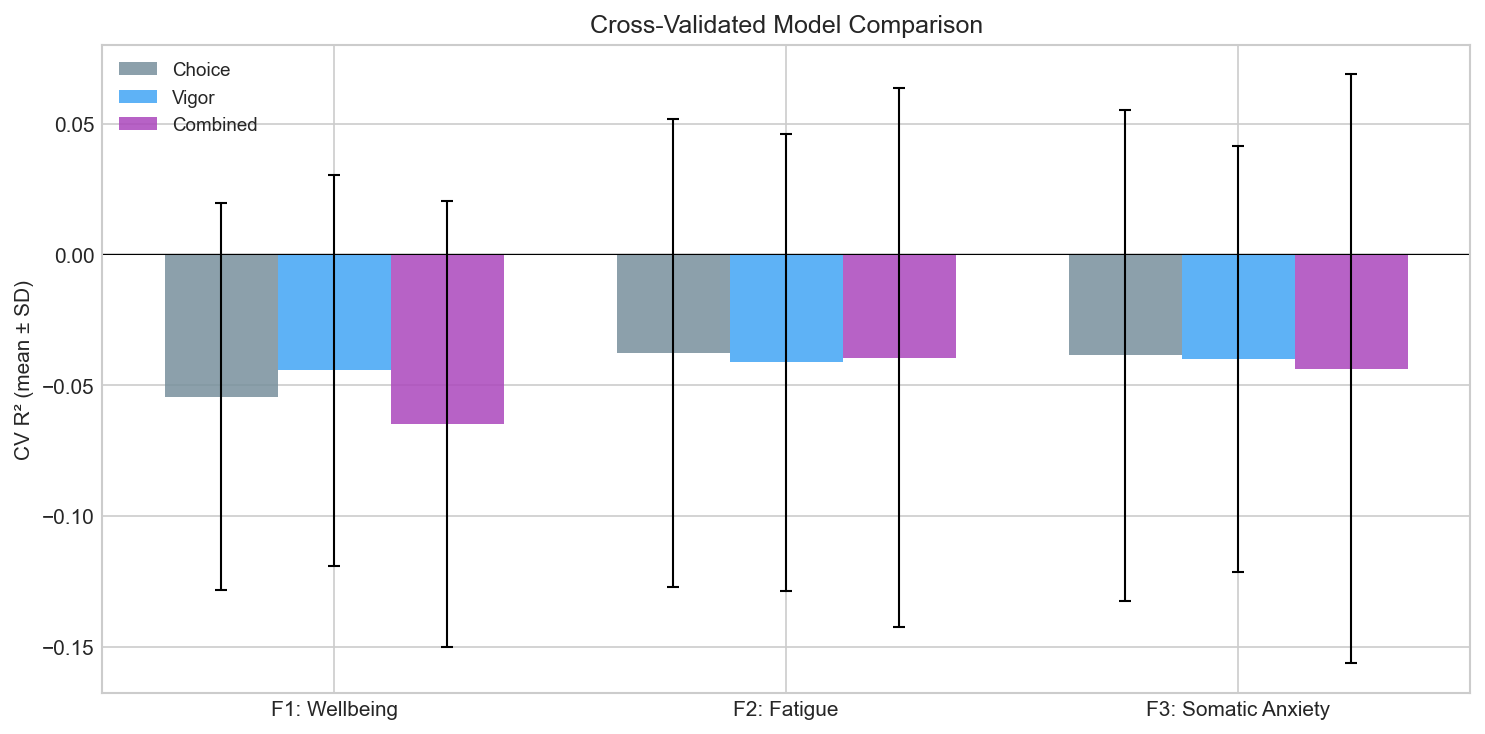

In [13]:
# ── CV comparison plot ──

fig, ax = plt.subplots(figsize=(10, 5), dpi=DPI)

x = np.arange(3)
width = 0.25
model_colors = {'Choice': '#78909C', 'Vigor': '#42A5F5', 'Combined': '#AB47BC'}

for k, model in enumerate(['Choice', 'Vigor', 'Combined']):
    subset = cv_df[cv_df['model'] == model]
    means = subset['cv_r2_mean'].values
    stds = subset['cv_r2_std'].values
    bars = ax.bar(x + k*width - width, means, width,
                   label=model, color=model_colors[model], alpha=0.85)
    ax.errorbar(x + k*width - width, means, yerr=stds,
                fmt='none', color='black', linewidth=1, capsize=3)

ax.set_xticks(x)
ax.set_xticklabels([factor_labels[f] for f in factor_cols], fontsize=10)
ax.set_ylabel('CV R² (mean ± SD)')
ax.set_title('Cross-Validated Model Comparison')
ax.legend(fontsize=9)
ax.axhline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig(FIG_DIR / 'vigor_nb4_cv_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## Section 7: Supplementary — Elastic Net Variable Selection

Data-driven complement to the theory-driven block analysis.
Reports which predictors survive penalization for each factor.

In [14]:
# ── Elastic Net ──

all_pred_cols = choice_cols + vigor_dims
X = df_complete[all_pred_cols].values
scaler = StandardScaler()

enet_results = []

for fc in factor_cols:
    fl = factor_labels[fc]
    y = df_complete[fc].values

    X_scaled = scaler.fit_transform(X)
    enet = ElasticNetCV(l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9],
                         cv=10, random_state=42, max_iter=10000)
    enet.fit(X_scaled, y)

    coefs = pd.Series(enet.coef_, index=all_pred_cols)
    surviving = coefs[coefs.abs() > 1e-5].sort_values(key=abs, ascending=False)

    print(f'\n{fl} (α={enet.alpha_:.4f}, l1_ratio={enet.l1_ratio_:.1f}):')
    print(f'  R² = {enet.score(X_scaled, y):.4f}')
    print(f'  Surviving predictors ({len(surviving)}/{len(all_pred_cols)}):')
    for pred, coef in surviving.items():
        block = 'ENER' if pred in ['kappa_z', 'tonic_vigor'] else 'THREAT'
        print(f'    {pred:30s}: {coef:+.4f}  [{block}]')

    for pred in all_pred_cols:
        enet_results.append({
            'outcome': fc, 'label': fl,
            'predictor': pred,
            'coef': coefs[pred],
            'survived': abs(coefs[pred]) > 1e-5,
        })

enet_df = pd.DataFrame(enet_results)



F1: Wellbeing (α=0.0903, l1_ratio=0.9):
  R² = 0.0109
  Surviving predictors (1/7):
    tonic_vigor                   : +0.0507  [ENER]

F2: Fatigue (α=0.0441, l1_ratio=0.9):
  R² = 0.0411
  Surviving predictors (4/7):
    z_z                           : -0.1216  [THREAT]
    reactive_spike                : -0.0684  [THREAT]
    tonic_vigor                   : +0.0499  [ENER]
    kappa_z                       : -0.0054  [ENER]

F3: Somatic Anxiety (α=0.0553, l1_ratio=0.9):
  R² = 0.0358
  Surviving predictors (2/7):
    z_z                           : -0.0992  [THREAT]
    tonic_vigor                   : -0.0843  [ENER]


## Section 8: Demographic Controls

Check whether results hold after controlling for Age and Sex.

In [15]:
# ── Rerun combined models with demographic covariates ──

# Encode Sex
df_complete['sex_male'] = (df_complete['Sex'] == 'Male').astype(float)

demo_formula = full_formula + ' + Age + sex_male'

print('Combined model + demographics (Age, Sex):')
print('=' * 70)

for fc in factor_cols:
    fl = factor_labels[fc]
    fit_base = smf.ols(f'{fc} ~ {full_formula}', data=df_complete).fit()
    fit_demo = smf.ols(f'{fc} ~ {demo_formula}', data=df_complete).fit()

    print(f'\n{fl}:')
    print(f'  Without demographics: adj.R² = {fit_base.rsquared_adj:.4f}')
    print(f'  With demographics:    adj.R² = {fit_demo.rsquared_adj:.4f}')

    # Check if key predictors survive
    print(f'  Key coefficients (with demographics):')
    for pred in choice_cols + vigor_dims:
        p = fit_demo.pvalues[pred]
        b = fit_demo.params[pred]
        stars = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        if p < .1:  # report marginally significant and better
            print(f'    {pred:30s}: β={b:+.3f}, p={p:.4f}{stars}')

    # Demographics themselves
    for demo in ['Age', 'sex_male']:
        p = fit_demo.pvalues[demo]
        b = fit_demo.params[demo]
        stars = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        print(f'    {demo:30s}: β={b:+.3f}, p={p:.4f}{stars}')


Combined model + demographics (Age, Sex):

F1: Wellbeing:
  Without demographics: adj.R² = 0.0028
  With demographics:    adj.R² = 0.0028
  Key coefficients (with demographics):
    tonic_vigor                   : β=+0.251, p=0.0337*
    Age                           : β=+0.076, p=0.2048
    sex_male                      : β=-0.077, p=0.5245

F2: Fatigue:
  Without demographics: adj.R² = 0.0249
  With demographics:    adj.R² = 0.0564
  Key coefficients (with demographics):
    z_z                           : β=-0.121, p=0.0448*
    tonic_vigor                   : β=+0.221, p=0.0552
    reactive_spike                : β=-0.130, p=0.0313*
    Age                           : β=-0.001, p=0.9874
    sex_male                      : β=-0.400, p=0.0008***

F3: Somatic Anxiety:
  Without demographics: adj.R² = 0.0189
  With demographics:    adj.R² = 0.0327
  Key coefficients (with demographics):
    z_z                           : β=-0.142, p=0.0196*
    tonic_vigor                   : β=-0.225

## Section 9: Save Results

In [16]:
# ── Save all results ──

# Model comparison
model_results_df.to_csv(RESULTS / 'clinical_model_comparison.csv', index=False)

# Full model coefficients
coef_df.to_csv(RESULTS / 'clinical_full_coefficients.csv', index=False)

# Block dissociation
block_df.to_csv(RESULTS / 'clinical_block_dissociation.csv', index=False)

# CV results
cv_df.to_csv(RESULTS / 'clinical_cv_results.csv', index=False)

# Elastic net
enet_df.to_csv(RESULTS / 'clinical_elastic_net.csv', index=False)

print('Saved:')
for f in ['clinical_model_comparison.csv', 'clinical_full_coefficients.csv',
          'clinical_block_dissociation.csv', 'clinical_cv_results.csv',
          'clinical_elastic_net.csv']:
    print(f'  {RESULTS / f}')


Saved:
  ../../results/clinical_model_comparison.csv
  ../../results/clinical_full_coefficients.csv
  ../../results/clinical_block_dissociation.csv
  ../../results/clinical_cv_results.csv
  ../../results/clinical_elastic_net.csv


## Summary

**Three psychiatric factors** predicted from 7 behavioral features (3 choice + 4 vigor).

**Factor structure:**
- F1 (Wellbeing): STAI positive affect, DASS/PHQ depression items (higher = better)
- F2 (Fatigue): MFIS items, PHQ fatigue/concentration (higher = more fatigued)
- F3 (Somatic Anxiety): DASS physical anxiety, STAI fear, OASIS (higher = more anxious)

**Key tests:**
1. Model comparison — does combining choice + vigor improve prediction over either alone?
2. Block dissociation — do energetic features (κ, tonic) predict depression/fatigue while threat features (β, z, anticipatory/reactive/terminal) predict anxiety?
3. Cross-validation — do effects hold out-of-sample?
4. Elastic net — data-driven convergence check on theory-driven blocks.
